---
title: Sentinel-2 Crop-Type Classification
subtitle: 
authors:
  - name: Suriyah Dhinakaran
    orcid: 0009-0007-0355-7372
    github: suriyahgit
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2025-10-21
thumbnail: https://raw.githubusercontent.com/EOPF-Sample-Service/eopf-sample-notebooks/refs/heads/main/notebooks/static/ESA_logo_2020_Deep.png
keywords: ["xarray", "earth observation", "remote sensing", "eopf-zarr", "scipy"]
tags: ["sentinel-2", "xarray", "land"]
releaseDate: 2025-10-21
datePublished: 2025-10-21
dateModified: 2025-10-21
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of Contents

- [Preface](#preface)
- [Introduction](#introduction)
- [Overview](#overview)
- [Setup](#setup)
- [Area of Interest](#area-of-interest)
- [Datacube Creation](#datacube-creation)
- [Random Sampling of Crop Points within Datacube Bounds](#random-sampling-of-crop-points-within-datacube-bounds)
- [Point-Series Extraction & NetCDF-Safe Export (with SCL masking)](#point-series-extraction--netcdf-safe-export-with-scl-masking)
- [Time-Series Extraction and NetCDF Export (Compute-Intensive Step)](#time-series-extraction-and-netcdf-export-compute-intensive-step)
- [NDVI Monthly Boxplot Generation for Crop Samples](#ndvi-monthly-boxplot-generation-for-crop-samples)
- [Data Access and Subsetting over a 5 × 5 km Crop Diversity Region in Belgium](#data-access-and-subsetting-over-a-5--5-km-crop-diversity-region-in-belgium)
- [Saving and Reloading the Clear-Sky Datacube](#saving-and-reloading-the-clear-sky-datacube)
- [Cloud & Artifact Masking via Per-Timestamp SCL Dilation](#cloud--artifact-masking-via-per-timestamp-scl-dilation)
- [Saving and Reloading the Cloud-Masked Dataset](#saving-and-reloading-the-cloud-masked-dataset)
- [NDVI Computation from Cloud-Masked Reflectance Data](#ndvi-computation-from-cloud-masked-reflectance-data)
- [Monthly Aggregation, Gap-Filling, and 12-Month Composites](#monthly-aggregation-gap-filling-and-12-month-composites)
- [Monthly Band-Stack Creation for NDVI, NIR, and SWIR Features](#monthly-band-stack-creation-for-ndvi-nir-and-swir-features)
- [Key Monthly Feature Selection for Rule Logic](#key-monthly-feature-selection-for-rule-logic)
- [Rule-Based Crop Classification Masks](#rule-based-crop-classification-masks)
- [Encoding Crop Classes into a Composite Map](#encoding-crop-classes-into-a-composite-map)
- [Categorical Crop Map Visualization](#categorical-crop-map-visualization)


## Preface

The original notebook used as a starting point for this work is a openEO platform example, [available here](https://github.com/openEOPlatform/SRR2_notebooks/blob/main/UC3%20-%20Crop%20type%20feature%20engineering%20(rule-based).ipynb). The example has been adapted to use the data provided by the EOPF Zarr Samples project instead of the openEO API.

## Introduction

This notebook demonstrates how to perform **rule-based crop-type classification** using **Sentinel-2 Level-2A data** accessed via the **EOPF STAC catalog**. The objective is to extract cloud-free reflectance signals, compute monthly vegetation indices, and apply phenology-driven rules to identify dominant crop types such as **maize, barley, sugar beet, potato, and soy**.

The workflow is structured as follows:

* **Data access**: Connect to the EOPF STAC API and load Sentinel-2 L2A Zarr cubes for reflectance (10 m, 20 m) and Scene Classification Layer (SCL) bands.
* **Preprocessing**: Apply an optimized, Dask-friendly variant of the `mask_scl_dilation` process to filter clouds, snow, and shadows while preserving valid vegetation pixels.
* **NDVI computation**: Derive NDVI from red (B04) and near-infrared (B08) bands and combine it with shortwave-infrared (B11) reflectance to form phenological features.
* **Temporal aggregation**: Resample data to monthly means, interpolate gaps, and generate 12-month composites representing seasonal vegetation dynamics.
* **Rule-based classification**: Use heuristic decision rules reflecting crop-specific NDVI and SWIR patterns to assign each pixel to a potential crop class.
* **Visualization**: Render the resulting categorical crop map with custom colors and legend annotations for easy interpretation.

This pipeline demonstrates how **clean, cloud-filtered Sentinel-2 time series** can be transformed into **phenology-based crop classification maps**, forming a foundation for scalable, interpretable, and region-specific agricultural monitoring workflows.

### Timeseries analysis of vegetation greenness  

Different land cover types can be identified by their seasonal **green-up** and **green-down** patterns. NDVI time series capture these phenological dynamics:  

- **Coniferous forests** remain green all year round, showing little variation in NDVI.  
- **Grasslands** show moderate seasonal cycles with higher values in spring and summer.  
- **Annual crops** (e.g., sugar beet, maize, potato) exhibit strong seasonal fluctuations, with steep green-up during growth, a pronounced peak, and rapid decline after harvest.  

An overview of NDVI trajectories for several crop types is shown in the plots below. These illustrate how **temporal profiles can serve as fingerprints** for distinguishing between vegetation classes.  

![Crop_Type_NDVI_Profiles](crop_types_plots.png)

:::{hint} Overview

**Questions**

* How can Sentinel-2 L2A data be accessed from a STAC catalog and preprocessed efficiently for large agricultural regions?
* What strategies can be used to minimize cloud and shadow contamination while preserving valid vegetation signals?
* How can NDVI and SWIR-based seasonal features be combined to capture phenological differences among crop types?
* Can rule-based logic derived from NDVI and reflectance patterns distinguish between major crops such as maize, barley, sugar beet, potato, and soy?
* How interpretable and transferable are these rule-based classifications across regions and seasons?

**Objectives**

* Retrieve and subset Sentinel-2 reflectance (B04, B08, B11) and Scene Classification (SCL) layers from an **EOPF STAC Zarr** catalog.
* Implement a **cloud-masking and dilation routine** inspired by the openEO `mask_scl_dilation` process to obtain clear-sky composites.
* Compute **NDVI and monthly reflectance features** capturing seasonal vegetation and moisture dynamics.
* Apply **phenology-driven, rule-based criteria** to classify pixels into crop categories such as maize, barley, sugar beet, potato, and soy.
* Visualize and analyze the resulting **crop-type map** to validate rule performance and identify mixed or uncertain areas.

:::

## Setup
Start importing the necessary libraries

In [1]:
import os
import warnings
from datetime import datetime
from pathlib import Path
import pathlib
from tqdm import tqdm

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

from shapely.geometry import Point, box
from scipy import ndimage as ndi
from pyproj import Transformer

import pystac_client

from dask_gateway import Gateway

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

In [2]:
# Simplest way - creates everything automatically in the eopf jupyterhub dask cluster

gate = Gateway()
cluster = gate.new_cluster()
cluster.scale(8)

# Area of Interest

The region of interest is located over the Belgium 31N tile, referenced in EPSG:32631. For the STAC query, the required input is the bounding box in EPSG:4326 (`bbox_4326`). Meanwhile, UTM-based slices are generated to subset the dataset, which is natively stored in UTM coordinates.

In [3]:
spatial_extent = {
    "west": 3.2865,
    "south": 50.7589,
    "east": 3.7752,
    "north": 50.9842,
}

bbox_4326 = [
    spatial_extent["west"],
    spatial_extent["south"],
    spatial_extent["east"],
    spatial_extent["north"],
]

OUT_BASE = pathlib.Path("outputs/samples_zarr")
OUT_BASE.mkdir(parents=True, exist_ok=True)

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32631", always_xy=True)
west_utm, south_utm = transformer.transform(
    spatial_extent["west"], spatial_extent["south"]
)
east_utm, north_utm = transformer.transform(
    spatial_extent["east"], spatial_extent["north"]
)

## Datacube Creation

Builds the time-indexed Sentinel-2 L2A datacube for the study area corresponding to the UTM 31N tiles.

In [4]:
# Spatial slice parameters
x_slice = slice(west_utm, east_utm)
y_slice = slice(north_utm, south_utm)

# Connect to the STAC catalog
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

# Search for Sentinel-2 L2A items within a specific bounding box and date range
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox_4326,
    datetime="2018-11-01/2020-02-01",
)

# Retrieve the list of matching items
items = list(search.items())
hrefs = [item.assets["product"].href for item in items]


def extract_time(ds):
    date_format = "%Y%m%dT%H%M%S"
    filename = ds.encoding["source"]
    date_str = os.path.basename(filename).split("_")[2]
    time = datetime.strptime(date_str, date_format)
    return ds.assign_coords(time=time)


datacube = xr.open_mfdataset(
    hrefs,
    engine="zarr",
    chunks={},
    group="/measurements/reflectance/r10m",
    concat_dim="time",
    combine="nested",
    preprocess=extract_time,
    mask_and_scale=True,
).sortby("time", ascending=True)

scl = xr.open_mfdataset(
    hrefs,
    engine="zarr",
    chunks={},
    group="/conditions/mask/l2a_classification/r20m",  # Adjust if necessary
    concat_dim="time",
    combine="nested",
    preprocess=extract_time,
    mask_and_scale=True,
).sortby("time", ascending=True)[["scl"]]


b11 = xr.open_mfdataset(
    hrefs,
    engine="zarr",
    chunks={},
    group="/measurements/reflectance/r20m",  # Adjust if necessary
    concat_dim="time",
    combine="nested",
    preprocess=extract_time,
    mask_and_scale=True,
).sortby("time", ascending=True)[["b11"]]

datacube = datacube.rio.write_crs("EPSG:32631")  # ensure CRS

datacube

<xarray.Dataset> Size: 691GB
Dimensions:      (time: 179, y: 10980, x: 10980)
Coordinates:
  * x            (x) float32 44kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
  * y            (y) float32 44kB 5.7e+06 5.7e+06 5.7e+06 ... 5.59e+06 5.59e+06
  * time         (time) datetime64[ns] 1kB 2018-11-02T10:52:09 ... 2020-01-31...
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 173GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 173GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 173GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, y, x) float64 173GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>

### **Random Sampling of Crop Points within Datacube Bounds**

This section defines utility functions to **generate spatial sample points** within the extent of the Sentinel-2 datacube.

* `_raster_bounds_polygon()` constructs a shapely bounding box of the raster area (in EPSG:32631).
* `_random_point_in_geom()` performs **rejection sampling** to select random points inside a given crop polygon.
* `simple_random_sampling_within_bounds()` integrates these helpers to identify polygons intersecting the datacube, choose a representative one per crop, and sample buffered points within it.

The output is a set of **GeoJSON feature collections**, each containing a small number of randomly distributed crop-specific sample areas (e.g., maize, barley, potato, sugar beet, soy) ready for time-series extraction and analysis.


In [5]:
def _raster_bounds_polygon(ds):
    """Shapely box of the datacube extent (expects x/y in EPSG:32631)."""
    xmin = float(ds.x.min())
    xmax = float(ds.x.max())
    ymin = float(ds.y.min())
    ymax = float(ds.y.max())
    return box(min(xmin, xmax), min(ymin, ymax), max(xmin, xmax), max(ymin, ymax))


def _random_point_in_geom(geom, rng=None, max_tries=10_000):
    """Rejection sample one point inside (multi)polygon."""
    if rng is None:
        rng = np.random.default_rng()
    minx, miny, maxx, maxy = geom.bounds
    for _ in range(max_tries):
        x = rng.uniform(minx, maxx)
        y = rng.uniform(miny, maxy)
        p = Point(x, y)
        if geom.contains(p):
            return p
    raise RuntimeError("Failed to sample a point inside geometry within max_tries.")


def simple_random_sampling_within_bounds(
    crop_samples, datacube, points_per_crop=5, buffer_m=20
):
    """
    Simple random sampling: find polygons within datacube bounds and pick 5 random points from them.
    Returns {crop_name: GeoJSON FeatureCollection (EPSG:32631)}
    """
    # Get datacube bounds
    raster_poly = _raster_bounds_polygon(datacube)

    points_per_type = {}

    for crop_name, gdf in crop_samples.items():
        # Ensure we have a valid GeoDataFrame with geometry
        if gdf.crs is None:
            gdf = gdf.set_crs("EPSG:4326")
        if gdf.crs.to_epsg() != 32631:
            gdf = gdf.to_crs("EPSG:32631")

        # Find polygons that intersect with datacube bounds
        polygons_within_bounds = []
        for idx, geometry in enumerate(gdf.geometry):
            if geometry.intersects(raster_poly):
                polygons_within_bounds.append((idx, geometry))

        if not polygons_within_bounds:
            print(
                f"Warning: No polygons for {crop_name} intersect with datacube bounds"
            )
            continue

        print(
            f"{crop_name}: {len(polygons_within_bounds)} polygons within datacube bounds"
        )

        # If we have polygons within bounds, pick one that fits well
        selected_polygons = []
        for idx, geometry in polygons_within_bounds:
            # Check if this polygon is mostly within the datacube bounds
            intersection = geometry.intersection(raster_poly)
            if (
                intersection.area > 0.5 * geometry.area
            ):  # At least 50% of polygon is within bounds
                selected_polygons.append((idx, geometry))
                # If we found one good polygon, use it for all 5 points
                if len(selected_polygons) >= 1:  # Just need one good polygon
                    break

        if not selected_polygons:
            # If no polygon is mostly within bounds, use the largest intersection
            largest_area = 0
            best_polygon = None
            for idx, geometry in polygons_within_bounds:
                intersection = geometry.intersection(raster_poly)
                if intersection.area > largest_area:
                    largest_area = intersection.area
                    best_polygon = (idx, geometry)
            if best_polygon:
                selected_polygons = [best_polygon]

        if not selected_polygons:
            print(f"Warning: No suitable polygon found for {crop_name}")
            continue

        # Use the first selected polygon to sample all 5 points
        poly_idx, selected_polygon = selected_polygons[0]
        print(
            f"Using polygon {poly_idx} for {crop_name} (area: {selected_polygon.area:.0f} m²)"
        )

        # Sample 5 random points from this single polygon
        buffered_points = []
        for i in range(points_per_crop):
            random_point = _random_point_in_geom(selected_polygon)
            buffered_point = random_point.buffer(buffer_m)
            buffered_points.append(buffered_point)

        # Create GeoDataFrame with buffered points
        result_gdf = gpd.GeoDataFrame(
            {
                "name": [crop_name] * len(buffered_points),
                "geometry": buffered_points,
                "polygon_index": [poly_idx]
                * len(buffered_points),  # Track which polygon was used
                "point_index": list(range(len(buffered_points))),  # Track point number
            },
            crs="EPSG:32631",
        )

        # Convert to GeoJSON string
        points_per_type[crop_name] = result_gdf.to_json()

    return points_per_type


crops = {"maize": 1200, "potatos": 5100, "sugarbeet": 8100, "barley": 1500, "soy": 4100}
crop_samples = {
    name: gpd.read_file("geojson/" + name + "_2019.geojson")
    for name, code in crops.items()
}

# Use the simple sampling
points_per_type = simple_random_sampling_within_bounds(
    crop_samples=crop_samples, datacube=datacube, points_per_crop=5, buffer_m=20
)

print(points_per_type.keys())

maize: 3 polygons within datacube bounds
Using polygon 1 for maize (area: 57299 m²)
potatos: 7 polygons within datacube bounds
Using polygon 1 for potatos (area: 3429 m²)
sugarbeet: 6 polygons within datacube bounds
Using polygon 0 for sugarbeet (area: 17616 m²)
barley: 7 polygons within datacube bounds
Using polygon 0 for barley (area: 26619 m²)
soy: 8 polygons within datacube bounds
Using polygon 0 for soy (area: 1302 m²)
dict_keys(['maize', 'potatos', 'sugarbeet', 'barley', 'soy'])


### **Point-Series Extraction & NetCDF-Safe Export (with SCL masking)**

This section bundles utilities to convert sampled crop locations into clean, 1-D time series and save them as **NetCDF** safely. It includes:

* **Attribute hygiene:** `_sanitize_netcdf_attrs()` removes/private-attrs and non-serializable metadata so files write cleanly.
* **Grid alignment & subsetting:** `_align_to_datacube_grid()` snaps arbitrary XY to the nearest raster cell; `_subset_window()` cuts a tiny window (single pixel or buffered) around the point.
* **Local resampling:** `_interp_like_local()` cheaply interpolates ancillary cubes (SCL, B11) onto the local window.
* **Cloud/shadow filtering:** `apply_simple_scl_mask()` masks **BAD_SCL** classes (shadow, clouds, cirrus, snow/ice) before index computation.
* **Band combine & reduction:** `_combine_and_reduce()` assembles B04, B08, B11, computes **NDVI**, and reduces the local window to a single time series via median/mean/nearest.
* **Point catalog handling:** `_geojsons_to_point_df()` turns per-crop GeoJSONs into a consolidated EPSG:32631 GeoDataFrame (using buffered-polygon centroids).
* **Main pipeline:** `extract_point_series_for_crops()` tries a **single-pixel** extraction first, falls back to a **buffered window** if data are all-NaN, then writes **one NetCDF per point** with sanitized attributes and returns a mapping `{(crop, point_idx): file_path}`.


In [6]:
def _sanitize_netcdf_attrs(ds: xr.Dataset) -> xr.Dataset:
    """
    Remove or stringify attrs that netCDF can't store (e.g., dicts, custom objects).
    Also drops private attrs starting with '_' (like '_eopf_attrs') to be safe.
    """

    def clean(mapping):
        bad_keys = []
        for k, v in list(mapping.items()):
            if k.startswith("_"):
                bad_keys.append(k)
                continue
            if isinstance(
                v, (str, bytes, int, float, bool, np.number, np.ndarray, list, tuple)
            ):
                # ok
                continue
            # dicts or anything else: either drop or stringify; here we drop
            bad_keys.append(k)
        for k in bad_keys:
            mapping.pop(k, None)

    ds = ds.copy(deep=False)
    clean(ds.attrs)
    for name, da in ds.variables.items():
        clean(da.attrs)
    return ds


def _align_to_datacube_grid(dc: xr.Dataset, x: float, y: float):
    """Return the nearest datacube x/y coordinates and their integer indices."""
    # nearest index lookup (works lazily with Dask)
    ix = int(abs(dc.x - x).argmin())
    iy = int(abs(dc.y - y).argmin())
    xg = float(dc.x.isel(x=ix))
    yg = float(dc.y.isel(y=iy))
    return ix, iy, xg, yg


def _subset_window(dc: xr.Dataset, x: float, y: float, buffer_m: float | int):
    """Subset a small x/y window around (x,y) from datacube using a metric buffer."""
    if buffer_m is None or buffer_m <= 0:
        # one pixel only
        ix, iy, xg, yg = _align_to_datacube_grid(dc, x, y)
        return dc.isel(x=slice(ix, ix + 1), y=slice(iy, iy + 1))
    # convert meters to number of 10 m pixels (ceil and add margin)
    px = int(np.ceil(buffer_m / 10.0))
    ix, iy, xg, yg = _align_to_datacube_grid(dc, x, y)
    xs = slice(max(ix - px, 0), ix + px + 1)
    ys = slice(max(iy - px, 0), iy + px + 1)
    return dc.isel(x=xs, y=ys)


def _interp_like_local(
    src: xr.Dataset | xr.DataArray, like: xr.Dataset
) -> xr.Dataset | xr.DataArray:
    """Cheap local resampling: resample only to the tiny 'like' grid."""
    # Use nearest to avoid introducing NaNs on tiny windows; it’s fast and robust
    return src.interp_like(like, method="nearest")


# Clouds & shadows (Sentinel-2 SCL): 3=Shadow, 8=Cloud medium, 9=Cloud high, 10=Thin cirrus, 11=Snow/Ice
BAD_SCL = [3, 8, 9, 10, 11]


def apply_simple_scl_mask(ds: xr.Dataset) -> xr.Dataset:
    if "scl" not in ds:  # if you didn't load SCL into the local window, do nothing
        return ds
    bad = ds["scl"].isin(BAD_SCL)
    out = ds.drop_vars("scl")  # keep only reflectances
    # mask each band where bad==True
    for v in out.data_vars:
        da = out[v]
        if np.issubdtype(da.dtype, np.integer):
            da = da.astype("float32")
        out[v] = da.where(~bad)
    return out


def _combine_and_reduce(
    dc_win: xr.Dataset, scl_win: xr.Dataset, b11_win: xr.Dataset, reduce: str = "median"
):
    """
    Combine bands and reduce spatial dims to a single time series.
    reduce: 'median' | 'mean' | 'nearest'
    """
    ds = xr.Dataset(
        {
            "b04": dc_win["b04"],
            "b08": dc_win["b08"],
            "b11": b11_win["b11"],
            "scl": scl_win["scl"],
        }
    )
    # NDVI
    ds = apply_simple_scl_mask(ds)
    ndvi = (ds.b08.astype("float32") - ds.b04.astype("float32")) / (ds.b08 + ds.b04)
    ndvi = ndvi.where((ds.b08 + ds.b04) != 0)
    ds = ds.assign(ndvi=ndvi)

    # collapse x,y to single point series
    if reduce == "nearest":
        ds = ds.isel(x=0, y=0)
    elif reduce == "mean":
        ds = ds.mean(dim=("y", "x"), skipna=True)
    else:
        ds = ds.median(dim=("y", "x"), skipna=True)

    return ds


def _geojsons_to_point_df(points_per_type: dict[str, str]) -> gpd.GeoDataFrame:
    """Turn your {crop: geojson_str} into a single EPSG:32631 GeoDataFrame with columns: name, point_index, geometry."""
    rows = []
    for crop, gj in points_per_type.items():
        gdf = gpd.read_file(gj)
        if gdf.crs is None:
            gdf = gdf.set_crs("EPSG:32631")
        elif gdf.crs.to_epsg() != 32631:
            gdf = gdf.to_crs("EPSG:32631")
        # Your sampling produced buffered polygons; use their centroids as the 'point'
        gdf = gdf.assign(
            name=crop, point_index=gdf.get("point_index", pd.Series(range(len(gdf))))
        )
        gdf["geometry"] = gdf.geometry.centroid
        rows.append(gdf[["name", "point_index", "geometry"]])
    if not rows:
        return gpd.GeoDataFrame(
            columns=["name", "point_index", "geometry"], crs="EPSG:32631"
        )
    return pd.concat(rows, ignore_index=True)


def extract_point_series_for_crops(
    datacube: xr.Dataset,
    scl: xr.Dataset,
    b11: xr.Dataset,
    points_per_type: dict[str, str],
    fallback_buffer_m: int = 20,
    reduce: str = "median",
    out_dir: pathlib.Path | str = "outputs/samples_netcdf",
) -> dict[tuple[str, int], str]:
    """
    For each crop point:
      1) try point-only resample (1 pixel)
      2) if any band is entirely NaN through time, retry with fallback_buffer_m window
      3) reduce to 1-D time series and save as <crop>_<seq>.nc (no appends)
    Returns {(crop, original_point_index): path}
    """
    out_dir = pathlib.Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    pts = _geojsons_to_point_df(points_per_type)
    if pts.empty:
        warnings.warn("No points to process.")
        return {}

    # ensure CRS is written (already done in your script)
    datacube = datacube.rio.write_crs("EPSG:32631")
    scl = scl.rio.write_crs("EPSG:32631")
    b11 = b11.rio.write_crs("EPSG:32631")

    results: dict[tuple[str, int], str] = {}
    # keep a per-crop sequential counter to guarantee 1..N filenames
    per_crop_counter: dict[str, int] = {}

    for _, row in tqdm(pts.iterrows(), total=len(pts), desc="Processing points"):
        crop = str(row["name"])
        pidx = int(row["point_index"])
        x = float(row.geometry.x)
        y = float(row.geometry.y)

        # 1) single-pixel attempt (cheapest)
        dc_win = _subset_window(datacube, x, y, buffer_m=0)
        scl_loc = _interp_like_local(scl, dc_win)
        b11_loc = _interp_like_local(b11, dc_win)
        ds_point = _combine_and_reduce(dc_win, scl_loc, b11_loc, reduce="nearest")

        # Check NaNs across key vars
        needs_fallback = False
        for var in ["b04", "b08", "b11"]:
            da = ds_point[var]
            if da.isnull().all():
                needs_fallback = True
                break

        # 2) fallback with small spatial window if needed
        if needs_fallback and fallback_buffer_m and fallback_buffer_m > 0:
            dc_win = _subset_window(datacube, x, y, buffer_m=fallback_buffer_m)
            scl_loc = _interp_like_local(scl, dc_win)
            b11_loc = _interp_like_local(b11, dc_win)
            ds_point = _combine_and_reduce(dc_win, scl_loc, b11_loc, reduce="median")

        # Determine sequential index (1..N) per crop for filename
        seq = per_crop_counter.get(crop, 0) + 1
        per_crop_counter[crop] = seq

        # Write a separate file, never append
        out_path = out_dir / f"{crop}_{seq}.nc"

        # This is a tiny dataset; persist shrinks the task graph
        ds_write = ds_point.persist()
        ds_write = _sanitize_netcdf_attrs(ds_write)

        # Overwrite if exists to keep clean, and write only this point
        ds_write.to_netcdf(out_path, mode="w")

        results[(crop, pidx)] = str(out_path)
        print(f"[{crop}:{pidx} -> seq {seq}] wrote {out_path}")

    return results

### **Time-Series Extraction and NetCDF Export (Compute-Intensive Step)**

This step executes the **per-crop time-series extraction** using the previously defined `extract_point_series_for_crops()` function. It loops through all sampled crop points, applies cloud masking and local reduction, and saves each resulting reflectance + NDVI series as individual **NetCDF files** in `outputs/samples_netcdf/`.

> ⚙️ **Note:** This step is computationally intensive — you may choose to **skip this cell** if you want to reduce execution time.

In [7]:
%%time

# Extract + save time-series per crop (1 sample per crop as configured)
saved = extract_point_series_for_crops(
    datacube=datacube,
    scl=scl,
    b11=b11,
    points_per_type=points_per_type,
    fallback_buffer_m=20,  # try single pixel first, then 20 m window if needed
    out_dir="outputs/samples_netcdf",
)

Processing points:   4%|▍         | 1/25 [00:42<16:56, 42.37s/it]

[maize:0 -> seq 1] wrote outputs/samples_netcdf/maize_1.nc


Processing points:   8%|▊         | 2/25 [01:16<14:26, 37.68s/it]

[maize:1 -> seq 2] wrote outputs/samples_netcdf/maize_2.nc


Processing points:  12%|█▏        | 3/25 [01:50<13:12, 36.01s/it]

...

[soy:2 -> seq 3] wrote outputs/samples_netcdf/soy_3.nc


Processing points:  96%|█████████▌| 24/25 [13:10<00:38, 38.68s/it]

[soy:3 -> seq 4] wrote outputs/samples_netcdf/soy_4.nc


Processing points: 100%|██████████| 25/25 [13:53<00:00, 33.35s/it]

[soy:4 -> seq 5] wrote outputs/samples_netcdf/soy_5.nc
Saved files: {('maize', 0): 'outputs/samples_netcdf/maize_1.nc', ('maize', 1): 'outputs/samples_netcdf/maize_2.nc', ('maize', 2): 'outputs/samples_netcdf/maize_3.nc', ('maize', 3): 'outputs/samples_netcdf/maize_4.nc', ('maize', 4): 'outputs/samples_netcdf/maize_5.nc', ('potatos', 0): 'outputs/samples_netcdf/potatos_1.nc', ('potatos', 1): 'outputs/samples_netcdf/potatos_2.nc', ('potatos', 2): 'outputs/samples_netcdf/potatos_3.nc', ('potatos', 3): 'outputs/samples_netcdf/potatos_4.nc', ('potatos', 4): 'outputs/samples_netcdf/potatos_5.nc', ('sugarbeet', 0): 'outputs/samples_netcdf/sugarbeet_1.nc', ('sugarbeet', 1): 'outputs/samples_netcdf/sugarbeet_2.nc', ('sugarbeet', 2): 'outputs/samples_netcdf/sugarbeet_3.nc', ('sugarbeet', 3): 'outputs/samples_netcdf/sugarbeet_4.nc', ('sugarbeet', 4): 'outputs/samples_netcdf/sugarbeet_5.nc', ('barley', 0): 'outputs/samples_netcdf/barley_1.nc', ('barley', 1): 'outputs/samples_netcdf/barley_2.nc', 

### **NDVI Monthly Boxplot Generation for Crop Samples**

This section visualizes **seasonal NDVI variations** across multiple crop types using the extracted time-series data.

* `_monthly_ndvi_series()` computes monthly mean NDVI values (January–December) for each sample file, handling missing or sparse observations gracefully.
* `prep_ndvi_boxplot_df()` aggregates all crop-wise NDVI series into a unified pandas DataFrame structured by crop, month, and sample iteration.
* `create_ndvi_boxplots()` generates **monthly NDVI boxplots** for each crop (maize, barley, sugar beet, potato, soy), showing how vegetation activity evolves through the year.

The resulting plots—saved in `outputs/ndvi_boxplots/`—help **compare phenological patterns** between crops and validate whether NDVI dynamics align with expected growing seasons.


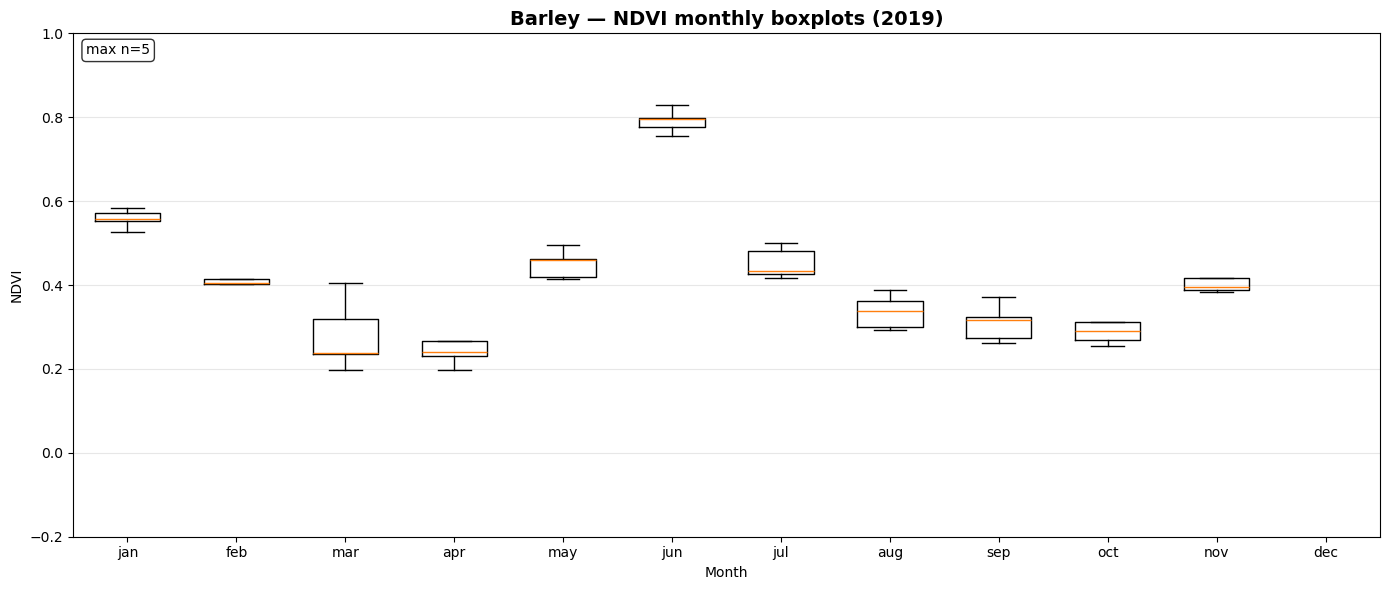

Saved: outputs/ndvi_boxplots/ndvi_boxplot_barley_2019.png


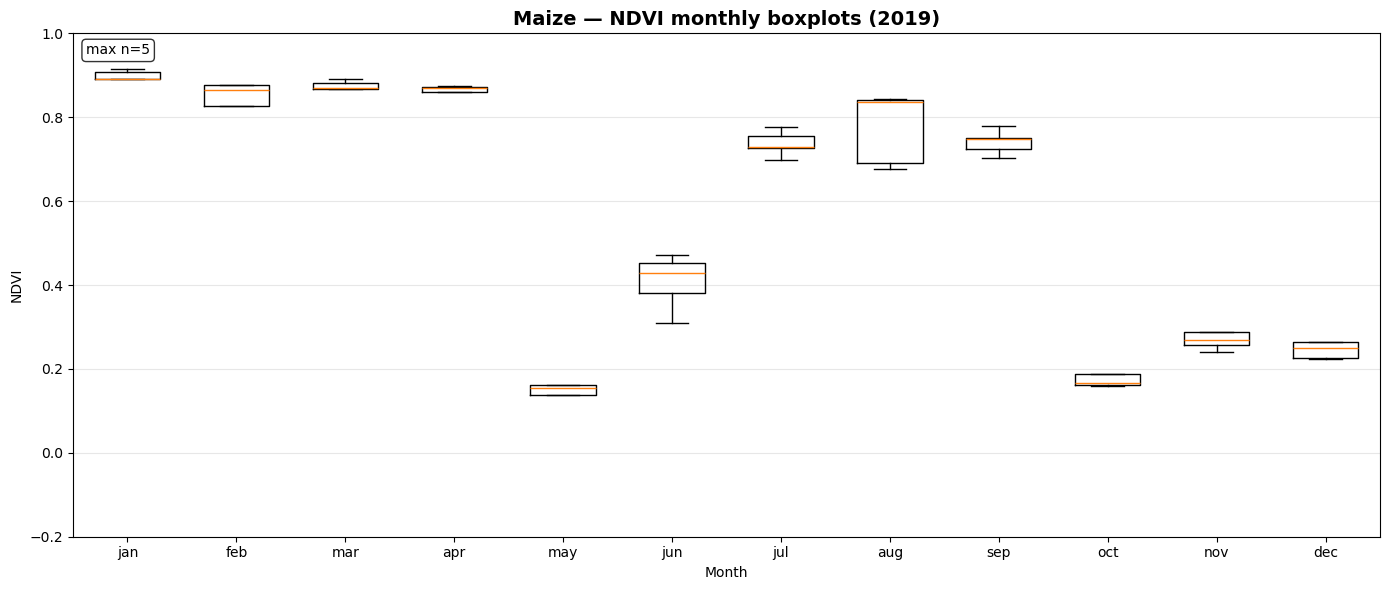

Saved: outputs/ndvi_boxplots/ndvi_boxplot_maize_2019.png


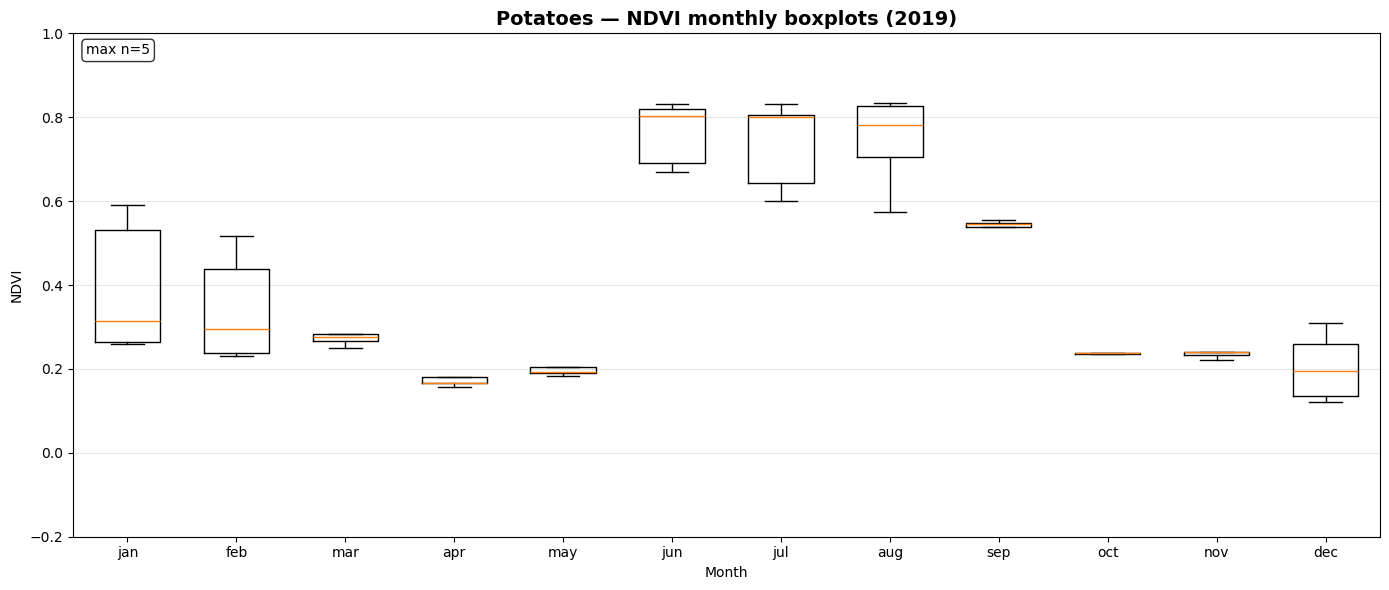

Saved: outputs/ndvi_boxplots/ndvi_boxplot_potatoes_2019.png


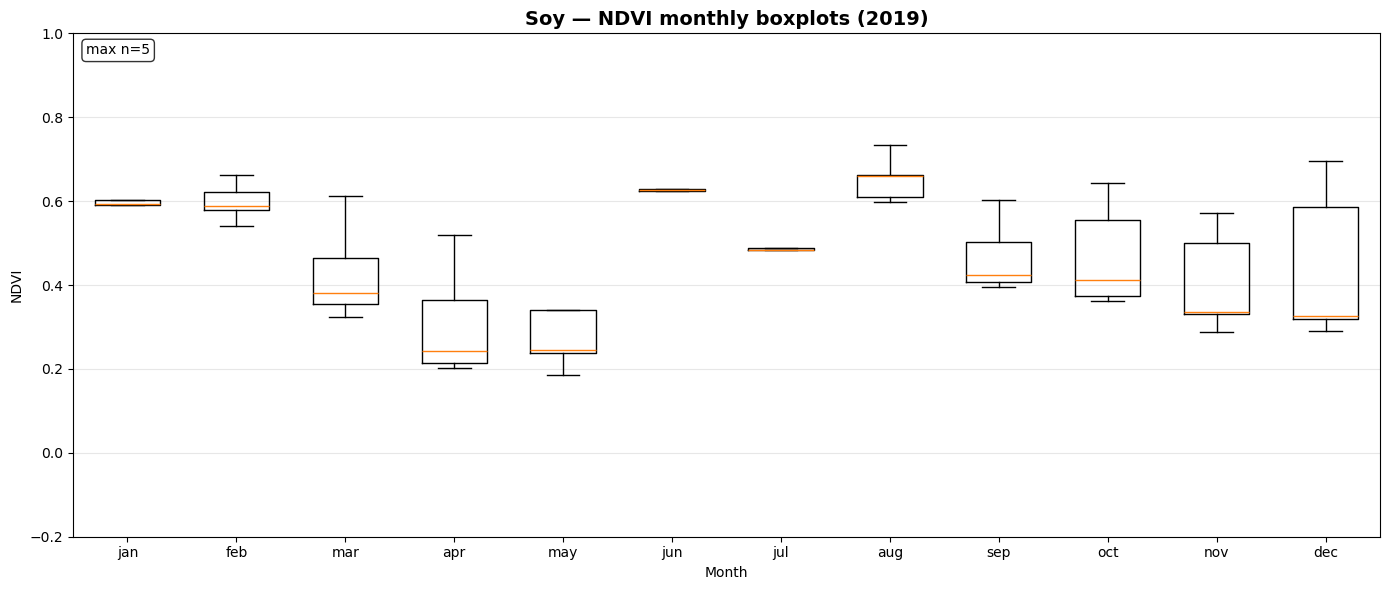

Saved: outputs/ndvi_boxplots/ndvi_boxplot_soy_2019.png


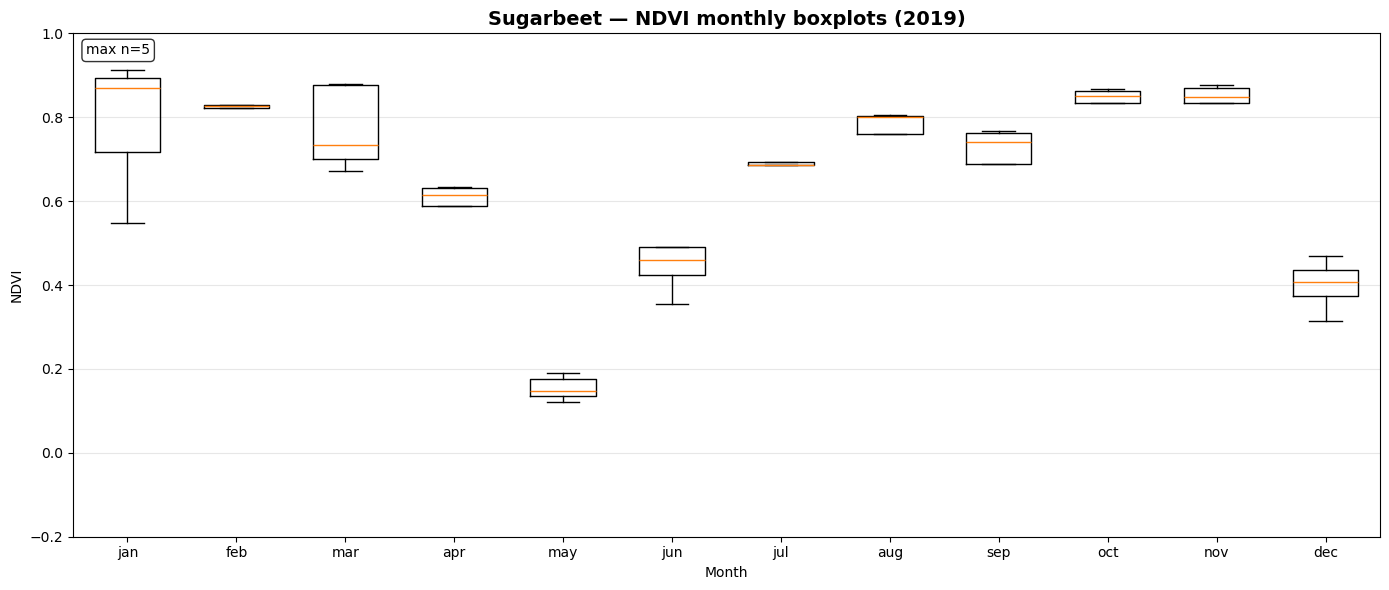

Saved: outputs/ndvi_boxplots/ndvi_boxplot_sugarbeet_2019.png


In [8]:
months = [
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]


def _monthly_ndvi_series(ds, year):
    """Return a 12-length array of monthly NDVI means (NaN where missing) for given year."""
    if "ndvi" not in ds.data_vars:
        return [np.nan] * 12

    ndvi = ds["ndvi"]
    if "time" not in ndvi.dims or ndvi.time.size == 0:
        return [np.nan] * 12

    time_values = pd.to_datetime(ndvi.time.values)
    values = np.asarray(ndvi.values, dtype=float)

    # Build a pandas Series and resample to month starts
    s = pd.Series(values, index=time_values)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        monthly = s.resample("MS").mean()  # monthly mean from available obs

    # Align to full year
    full = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31", freq="MS")
    out = []
    for t in full:
        v = monthly.get(t, np.nan)
        out.append(np.nan if pd.isna(v) else float(v))
    return out  # length 12


def prep_ndvi_boxplot_df(results_dict, year):
    rows = []
    for (crop_type, point_idx), file_path in results_dict.items():
        try:
            ds = xr.open_dataset(file_path)
        except Exception as e:
            print(f"Skip {file_path}: {e}")
            continue

        try:
            monthly12 = _monthly_ndvi_series(ds, year)
        finally:
            ds.close()

        for month_idx, v in enumerate(monthly12, start=1):
            rows.append(
                {
                    "Crop": crop_type,
                    "MonthIdx": month_idx,
                    "Month": months[month_idx - 1],
                    "Iteration": f"{crop_type}_{point_idx}",
                    "NDVI": v,
                }
            )
    df = pd.DataFrame(rows)
    # Keep only the target year’s rows (already ensured), drop all-NaN rows cleanly
    return df


def create_ndvi_boxplots(results_dict, year=2019, save_dir="outputs/ndvi_boxplots"):
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    df = prep_ndvi_boxplot_df(results_dict, year)

    if df.empty or df["NDVI"].notna().sum() == 0:
        print("No NDVI data available to plot.")
        return

    crops = sorted(df["Crop"].unique())
    for crop in crops:
        sub = df[(df["Crop"] == crop) & df["NDVI"].notna()].copy()
        if sub.empty:
            print(f"No NDVI data for {crop}")
            continue

        # Gather per-month arrays (list of arrays length 12)
        month_arrays = []
        counts = []
        for m in range(1, 13):
            vals = sub.loc[sub["MonthIdx"] == m, "NDVI"].values
            vals = vals[~np.isnan(vals)]
            month_arrays.append(vals)
            counts.append(len(vals))

        fig, ax = plt.subplots(figsize=(14, 6))
        ax.boxplot(month_arrays, showfliers=False, widths=0.6, tick_labels=months)

        ax.set_title(
            f"{crop.title()} — NDVI monthly boxplots ({year})",
            fontsize=14,
            fontweight="bold",
        )
        ax.set_xlabel("Month")
        ax.set_ylabel("NDVI")
        # NDVI can be [-1, 1]; tighten a bit while being safe
        y_min = min([-0.2, np.nanmin(sub["NDVI"]) if sub["NDVI"].size else -0.2])
        y_max = max([1.0, np.nanmax(sub["NDVI"]) if sub["NDVI"].size else 1.0])
        ax.set_ylim(y_min, y_max)

        # light grid on y
        ax.yaxis.grid(True, alpha=0.3)

        # annotate max sample count
        ax.text(
            0.01,
            0.98,
            f"max n={max(counts) if counts else 0}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        )

        plt.tight_layout()
        out_path = Path(save_dir) / f"ndvi_boxplot_{crop}_{year}.png"
        plt.savefig(out_path, dpi=200)
        plt.show()
        print(f"Saved: {out_path}")


results_dict = {
    # Maize - 30 samples
    ("maize", 0): "outputs/samples_netcdf/maize_1.nc",
    ("maize", 1): "outputs/samples_netcdf/maize_2.nc",
    ("maize", 2): "outputs/samples_netcdf/maize_3.nc",
    ("maize", 3): "outputs/samples_netcdf/maize_4.nc",
    ("maize", 4): "outputs/samples_netcdf/maize_5.nc",
    # Potatoes - 30 samples (corrected spelling from 'potatos' to 'potatoes')
    ("potatoes", 0): "outputs/samples_netcdf/potatos_1.nc",
    ("potatoes", 1): "outputs/samples_netcdf/potatos_2.nc",
    ("potatoes", 2): "outputs/samples_netcdf/potatos_3.nc",
    ("potatoes", 3): "outputs/samples_netcdf/potatos_4.nc",
    ("potatoes", 4): "outputs/samples_netcdf/potatos_5.nc",
    # Sugarbeet - 30 samples
    ("sugarbeet", 0): "outputs/samples_netcdf/sugarbeet_1.nc",
    ("sugarbeet", 1): "outputs/samples_netcdf/sugarbeet_2.nc",
    ("sugarbeet", 2): "outputs/samples_netcdf/sugarbeet_3.nc",
    ("sugarbeet", 3): "outputs/samples_netcdf/sugarbeet_4.nc",
    ("sugarbeet", 4): "outputs/samples_netcdf/sugarbeet_5.nc",
    # Barley - 30 samples
    ("barley", 0): "outputs/samples_netcdf/barley_1.nc",
    ("barley", 1): "outputs/samples_netcdf/barley_2.nc",
    ("barley", 2): "outputs/samples_netcdf/barley_3.nc",
    ("barley", 3): "outputs/samples_netcdf/barley_4.nc",
    ("barley", 4): "outputs/samples_netcdf/barley_5.nc",
    # Soy - 30 samples
    ("soy", 0): "outputs/samples_netcdf/soy_1.nc",
    ("soy", 1): "outputs/samples_netcdf/soy_2.nc",
    ("soy", 2): "outputs/samples_netcdf/soy_3.nc",
    ("soy", 3): "outputs/samples_netcdf/soy_4.nc",
    ("soy", 4): "outputs/samples_netcdf/soy_5.nc",
}

# run
create_ndvi_boxplots(results_dict, year=2019)

### **Data Access and Subsetting over a 5 × 5 km Crop Diversity Region in Belgium**

This section connects to the **EOPF STAC catalog** and retrieves **Sentinel-2 Level-2A** Zarr datasets for a carefully selected **5 km × 5 km region in Belgium**. The chosen area was identified because it contains **all five target crop types**—maize, barley, sugar beet, potato, and soy—making it an ideal test patch for classification and phenological analysis.

The workflow:

* Defines the **spatial extent and bounding box** (EPSG:4326 and EPSG:32631) covering the region.
* Connects to the **EOPF STAC API** to query Sentinel-2 L2A scenes between **November 2018 and February 2020**.
* Loads the **Scene Classification Layer (SCL)**, filters clear-sky observations (classes 4–6), and selects time steps with at least 10 % valid pixels.
* Opens corresponding **reflectance (B04, B08, B11)** cubes and resamples them to the same grid.
* Produces a **cloud-filtered, spatially consistent datacube** that will serve as the foundation for NDVI computation and crop-type classification.


In [9]:
def extract_time(ds):
    date_format = "%Y%m%dT%H%M%S"
    filename = ds.encoding["source"]
    date_str = os.path.basename(filename).split("_")[2]
    time = datetime.strptime(date_str, date_format)
    return ds.assign_coords(time=time)


spatial_extent = {
    "west": 3.2865,
    "south": 50.7589,
    "east": 3.7752,
    "north": 50.9842,
}

bbox_4326 = [
    spatial_extent["west"],
    spatial_extent["south"],
    spatial_extent["east"],
    spatial_extent["north"],
]

# Spatial slice parameters
x_slice = slice(549400, 554400)
y_slice = slice(5641500, 5636500)

# Connect to the STAC catalog
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

# Search for Sentinel-2 L2A items within a specific bounding box and date range
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox_4326,
    datetime="2018-11-01/2020-02-01",
)

# Retrieve the list of matching items
items = list(search.items())
hrefs = [item.assets["product"].href for item in items]

scl = (
    xr.open_mfdataset(
        hrefs,
        engine="zarr",
        chunks={},
        group="/conditions/mask/l2a_classification/r20m",  # Adjust if necessary
        concat_dim="time",
        combine="nested",
        preprocess=extract_time,
        mask_and_scale=True,
    )
    .sortby("time", ascending=True)[["scl"]]
    .sel(x=x_slice, y=y_slice)
    .compute()
)

valid_classes = [4, 5, 6]
threshold = 0.1

clear_mask = scl["scl"].isin(valid_classes)

clear_fraction = clear_mask.mean(dim=("y", "x")).compute()

mask_good = clear_fraction >= threshold

datacube_clear = (
    xr.open_mfdataset(
        hrefs,
        engine="zarr",
        chunks={},
        group="/measurements/reflectance/r10m",
        concat_dim="time",
        combine="nested",
        preprocess=extract_time,
        mask_and_scale=True,
    )
    .sortby("time", ascending=True)
    .isel(time=mask_good)
    .sel(x=x_slice, y=y_slice)
    .compute()
)

b11_clear = (
    xr.open_mfdataset(
        hrefs,
        engine="zarr",
        chunks={},
        group="/measurements/reflectance/r20m",  # Adjust if necessary
        concat_dim="time",
        combine="nested",
        preprocess=extract_time,
        mask_and_scale=True,
    )
    .sortby("time", ascending=True)[["b11"]]
    .isel(time=mask_good)
    .sel(x=x_slice, y=y_slice)
    .compute()
)

scl_clear = scl.isel(time=mask_good)
scl_resampled = scl_clear.scl.interp_like(datacube_clear, method="nearest")
b11_resampled = b11_clear.b11.interp_like(datacube_clear, method="nearest")

datacube_clear["scl"] = scl_resampled
datacube_clear["b11"] = b11_resampled

datacube_clear = datacube_clear.rio.write_crs("EPSG:32631")  # ensure CRS

datacube_clear

<xarray.Dataset> Size: 420MB
Dimensions:      (time: 35, y: 500, x: 500)
Coordinates:
  * x            (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y            (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
  * time         (time) datetime64[ns] 280B 2018-11-02T10:52:09 ... 2020-01-0...
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 70MB 0.0295 0.0272 ... 0.0304 0.0409
    b03          (time, y, x) float64 70MB 0.063 0.0586 0.0608 ... 0.0406 0.0417
    b04          (time, y, x) float64 70MB 0.0278 0.0263 ... 0.0433 0.0474
    b08          (time, y, x) float64 70MB 0.5619 0.506 0.3667 ... 0.134 0.1704
    scl          (time, y, x) float64 70MB nan nan nan nan ... nan nan nan nan
    b11          (time, y, x) float64 70MB nan nan nan nan ... nan nan nan nan

### **Saving and Reloading the Clear-Sky Datacube**

This step saves the processed **cloud-filtered Sentinel-2 datacube** to disk and reloads it for subsequent analysis. This approach provides a lightweight, reusable version of the **clean Sentinel-2 reflectance datacube**, ready for NDVI computation, temporal aggregation, and rule-based crop classification.


In [10]:
datacube_clear.to_dataarray().to_netcdf("outputs/datacube_clear.nc")
datacube_clear = xr.open_dataarray("outputs/datacube_clear.nc").to_dataset(
    dim="variable"
)
datacube_clear

<xarray.Dataset> Size: 420MB
Dimensions:      (time: 35, y: 500, x: 500)
Coordinates:
  * x            (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y            (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
  * time         (time) datetime64[ns] 280B 2018-11-02T10:52:09 ... 2020-01-0...
    spatial_ref  int64 8B ...
Data variables:
    b02          (time, y, x) float64 70MB ...
    b03          (time, y, x) float64 70MB ...
    b04          (time, y, x) float64 70MB ...
    b08          (time, y, x) float64 70MB ...
    scl          (time, y, x) float64 70MB ...
    b11          (time, y, x) float64 70MB ...

### **Cloud & Artifact Masking via Per-Timestamp SCL Dilation**

This section implements a **direct, per-time-step** version of `mask_scl_dilation` to aggressively remove cloud, shadow, and adjacency effects from Sentinel-2 scenes.

* Builds circular **morphological kernels** (r=8 px and r=100 px) and dilates two masks: one for **non-valid classes** and one for **cloud/shadow/snow** classes.
* Applies the combined mask to **all reflectance bands** (leaving SCL untouched), replacing contaminated pixels with `NaN`.
* **Keeps only time steps** that retain any valid (non-NaN) data after masking, then concatenates them back into a cleaned time series.

> ⚙️ Note: The large-radius dilation (r=100) can be **CPU/memory intensive**; consider reducing the radius if you encounter resource limits.


In [11]:
def circular_kernel(radius: int) -> np.ndarray:
    """Create a 2D circular (disk) kernel with given radius in pixels."""
    r = int(radius)
    y, x = np.ogrid[-r : r + 1, -r : r + 1]
    k = (x * x + y * y) <= (r * r)
    return k.astype(np.float32)


def _dilate_with_convolve(mask_2d: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """
    Dilate a boolean mask using convolution with a (0/1) kernel.
    Returns a boolean array where any overlap with the kernel sets True.
    """
    if mask_2d.dtype != np.float32:
        mask_2d = mask_2d.astype(np.float32, copy=False)
    # Convolution counts how many True pixels fall under the kernel footprint.
    conv = ndi.convolve(mask_2d, kernel, mode="constant", cval=0.0)
    return conv > 0.0


def mask_scl_dilation_direct(
    ds: xr.Dataset, *, time_band_name: str = "time", scl_band_name: str = "scl"
) -> xr.Dataset:
    """
    Direct implementation of mask_scl_dilation that processes each time step individually.
    """
    if scl_band_name not in ds:
        raise ValueError(
            f"{scl_band_name!r} not found in dataset variables: {list(ds.data_vars)}"
        )

    if time_band_name not in ds.dims:
        raise ValueError(
            f"{time_band_name!r} not found in dataset dimensions: {list(ds.dims)}"
        )

    scl = ds[scl_band_name]

    # Figure out spatial dimensions
    cand_xy = [d for d in ["y", "x"] if d in scl.dims]
    if len(cand_xy) != 2:
        cand_xy = list(scl.dims[-2:])
    ydim, xdim = cand_xy

    # Precompute kernels
    kernel1 = circular_kernel(radius=8).astype(np.float32)
    kernel2 = circular_kernel(radius=20).astype(np.float32)

    bands_to_mask = [v for v in ds.data_vars if v != scl_band_name]

    # Process each time step directly
    time_steps = ds[time_band_name].values
    masked_time_slices = []
    valid_times = []

    for i, time_val in tqdm(
        enumerate(time_steps), total=len(time_steps), desc="Processing time steps"
    ):
        # Extract single time step
        time_slice = ds.sel({time_band_name: time_val})
        scl_slice = scl.sel({time_band_name: time_val})

        # Convert to numpy arrays for direct processing
        scl_2d = scl_slice.values

        # Apply dilation logic directly
        mask1 = (
            (scl_2d != 2)
            & (scl_2d != 4)
            & (scl_2d != 5)
            & (scl_2d != 6)
            & (scl_2d != 7)
        )
        mask2 = (
            (scl_2d == 3)
            | (scl_2d == 8)
            | (scl_2d == 9)
            | (scl_2d == 10)
            | (scl_2d == 11)
        )

        dil1 = _dilate_with_convolve(
            mask1, kernel1
        )  # That problematic step that leads the kernel in the eodc jupyterlab to crash

        dil2 = _dilate_with_convolve(
            mask2, kernel2
        )  # That problematic step that leads the kernel in the eodc jupyterlab to crash
        combined_mask = dil1 | dil2

        # Apply mask to all bands except SCL
        masked_slice = time_slice.copy()
        has_valid_data = False

        for var in bands_to_mask:
            band_data = time_slice[var].values
            if np.issubdtype(band_data.dtype, np.integer):
                # Convert to float to support NaN
                band_data = band_data.astype(np.float32)
                band_data[combined_mask] = np.nan
                masked_slice[var] = ([ydim, xdim], band_data)
            else:
                band_data = band_data.copy()
                band_data[combined_mask] = np.nan
                masked_slice[var] = ([ydim, xdim], band_data)

            # Check if this band has any valid data in this time step
            if not has_valid_data and np.any(~np.isnan(band_data)):
                has_valid_data = True

        # Only keep time steps with valid data
        if has_valid_data:
            masked_time_slices.append(masked_slice)
            valid_times.append(time_val)

    # Reconstruct dataset with only valid time steps
    if masked_time_slices:
        # Combine all valid time slices
        result = xr.concat(masked_time_slices, dim=time_band_name)
        # Ensure time coordinate is preserved correctly
        result[time_band_name] = valid_times
    else:
        # No valid time steps - return empty dataset with same structure
        result = ds.isel({time_band_name: []})

    return result


masked_ds = mask_scl_dilation_direct(
    datacube_clear, time_band_name="time", scl_band_name="scl"
)
masked_ds

Processing time steps: 100%|██████████| 35/35 [00:13<00:00,  2.64it/s]


<xarray.Dataset> Size: 420MB
Dimensions:      (time: 35, y: 500, x: 500)
Coordinates:
  * x            (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y            (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
  * time         (time) datetime64[ns] 280B 2018-11-02T10:52:09 ... 2020-01-0...
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 70MB nan nan nan nan ... nan nan nan nan
    b03          (time, y, x) float64 70MB nan nan nan nan ... nan nan nan nan
    b04          (time, y, x) float64 70MB nan nan nan nan ... nan nan nan nan
    b08          (time, y, x) float64 70MB nan nan nan nan ... nan nan nan nan
    scl          (time, y, x) float64 70MB nan nan nan nan ... nan nan nan nan
    b11          (time, y, x) float64 70MB nan nan nan nan ... nan nan nan nan

### **Saving and Reloading the Cloud-Masked Dataset**

This step exports the **cloud-filtered Sentinel-2 dataset** produced by the `mask_scl_dilation_direct()` function and reloads it for verification. This ensures the **cloud-masked datacube** is safely persisted to disk and ready for downstream NDVI computation and temporal aggregation.


In [12]:
masked_ds.to_dataarray().to_netcdf("outputs/masked_ds.nc")
masked_ds_check = xr.open_dataarray("outputs/masked_ds.nc").to_dataset(dim="variable")
masked_ds_check

<xarray.Dataset> Size: 420MB
Dimensions:      (time: 35, y: 500, x: 500)
Coordinates:
  * x            (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y            (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
  * time         (time) datetime64[ns] 280B 2018-11-02T10:52:09 ... 2020-01-0...
    spatial_ref  int64 8B ...
Data variables:
    b02          (time, y, x) float64 70MB ...
    b03          (time, y, x) float64 70MB ...
    b04          (time, y, x) float64 70MB ...
    b08          (time, y, x) float64 70MB ...
    scl          (time, y, x) float64 70MB ...
    b11          (time, y, x) float64 70MB ...

### **NDVI Computation from Cloud-Masked Reflectance Data**

This section derives the **Normalized Difference Vegetation Index (NDVI)** from the cloud-free Sentinel-2 datacube.

* Uses the **near-infrared (B08)** and **red (B04)** reflectance bands to compute:
  [
  \text{NDVI} = \frac{B08 - B04}{B08 + B04}
  ]
* Ensures numerical stability by handling divisions where the denominator is zero and casting values to `float32` precision.
* Returns a new DataArray named **`NDVI`**, representing vegetation vigor for each pixel and time step.

This NDVI layer forms the foundation for analyzing vegetation dynamics and distinguishing different crop phenologies.


In [13]:
def compute_ndvi(ds: xr.Dataset) -> xr.DataArray:
    nir = ds["b08"].astype("float32")
    red = ds["b04"].astype("float32")
    num = nir - red
    den = nir + red
    ndvi = xr.where(den != 0, num / den, np.nan)
    ndvi.name = "NDVI"
    return ndvi


ndvi_dataset = compute_ndvi(masked_ds_check)
ndvi_dataset

<xarray.DataArray 'NDVI' (time: 35, y: 500, x: 500)> Size: 35MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * x            (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y            (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
  * time         (time) datetime64[ns] 280B 2018-11-02T10:52:09 ... 2020-01-0...
    spatial_ref  int64 8B 0

### **Monthly Aggregation, Gap-Filling, and 12-Month Composites**

This section converts the cloud-masked dataset into **monthly features** suitable for phenology analysis:

* Resamples to **month starts (1MS)** and computes monthly means.
* Reindexes to a continuous monthly timeline and **linearly interpolates** small gaps (limit = 1 month).
* Clips NDVI to **[0, 1]** and then averages by `time.month` to produce a **12 month composites** (Jan–Dec) for each variable.

In [14]:
masked_ds_check["ndvi"] = ndvi_dataset
monthly = masked_ds_check.resample(time="1MS").mean(skipna=True)
full_index = pd.date_range(
    monthly.time.min().values, monthly.time.max().values, freq="1MS"
)
monthly = monthly.reindex(time=full_index)

monthly = monthly.interpolate_na(
    dim="time", method="linear", use_coordinate="time", limit=1
)
monthly["ndvi"] = monthly["ndvi"].clip(0, 1)
monthly = monthly.groupby("time.month").mean("time", skipna=True)
monthly

<xarray.Dataset> Size: 156MB
Dimensions:      (month: 12, y: 500, x: 500)
Coordinates:
  * x            (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y            (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
    spatial_ref  int64 8B 0
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    b02          (month, y, x) float64 24MB nan nan nan nan ... nan nan nan nan
    b03          (month, y, x) float64 24MB nan nan nan nan ... nan nan nan nan
    b04          (month, y, x) float64 24MB nan nan nan nan ... nan nan nan nan
    b08          (month, y, x) float64 24MB nan nan nan nan ... nan nan nan nan
    scl          (month, y, x) float64 24MB nan nan nan nan ... nan nan nan nan
    b11          (month, y, x) float64 24MB nan nan nan nan ... nan nan nan nan
    ndvi         (month, y, x) float32 12MB nan nan nan nan ... nan nan nan nan

### **Monthly Band-Stack Creation for NDVI, NIR, and SWIR Features**

This section restructures the 12-month climatology into a **band-stacked dataset** that’s easier to use for classification and visualization.

* `rename_monthly_vars()` renames each month of a given variable (e.g., `ndvi`, `b08`, `b11`) into distinct **band names** like `NDVI_jan`, `NDVI_feb`, …, `NDVI_dec`.
* The resulting monthly layers for NDVI, NIR (B08), and SWIR (B11) are concatenated along a new **`band` dimension**, forming a single 3D array `(band, y, x)`.
* This compact stack captures **seasonal reflectance and vegetation dynamics** across all months, serving as the **feature base** for rule-based or machine learning–based crop classification.

In [15]:
def rename_monthly_vars(monthly_ds, varname):
    # monthly_ds[varname] has dims (month, y, x); create a new band dimension with names <var>_<mon>
    arr = monthly_ds[varname]  # (month, y, x)
    arr = arr.assign_coords(month=months)  # label 1..12 with names
    stacked = xr.concat([arr.sel(month=m) for m in months], dim="band")
    stacked = stacked.assign_coords(band=[f"{varname.upper()}_{m}" for m in months])
    return stacked  # (band, y, x)


ndvi_bands = rename_monthly_vars(monthly, "ndvi")  # bands: NDVI_jan..NDVI_dec
b08_bands = rename_monthly_vars(monthly, "b08")  # B08_*
b11_bands = rename_monthly_vars(monthly, "b11")  # B11_*

all_bands = xr.concat([ndvi_bands, b08_bands, b11_bands], dim="band")  # (band, y, x)
all_bands

<xarray.DataArray 'ndvi' (band: 36, y: 500, x: 500)> Size: 72MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * x            (x) float32 2kB 5.494e+05 5.494e+05 ... 5.544e+05 5.544e+05
  * y            (y) float32 2kB 5.641e+06 5.641e+06 ... 5.637e+06 5.637e+06
    spatial_ref  int64 8B 0
    month        (band) <U3 432B 'jan' 'feb' 'mar' 'apr' ... 'oct' 'nov' 'dec'
  * band         (band) <U8 1kB 'NDVI_jan' 'NDVI_feb' ... 'B11_nov' 'B11_dec'

### **Key Monthly Feature Selection for Rule Logic**

This section extracts a **targeted subset of monthly bands** from the stacked feature cube to drive interpretable, rule-based classification. By focusing on months that best capture crop phenology (spring green-up, summer peak, and autumn senescence), we reduce noise and keep features meaningful.

* **NDVI features:** `NDVI_jan, _apr, _may, _jun, _jul, _aug, _sep, _oct, _nov` — track vegetation onset, peak growth, and decline.
* **NIR (B08) features:** `B08_mar, _may, _jun, _oct` — sensitive to canopy structure and biomass.
* **SWIR (B11) features:** `B11_mar, _apr, _may, _oct` — informative for moisture/stress and residue.

These focused features provide clear seasonal signals that differentiate maize, barley, sugar beet, potato, and soy with simple, transparent rules.

In [16]:
ndvi_jan = all_bands.sel(band="NDVI_jan")
ndvi_apr = all_bands.sel(band="NDVI_apr")
ndvi_may = all_bands.sel(band="NDVI_may")
ndvi_jun = all_bands.sel(band="NDVI_jun")
ndvi_jul = all_bands.sel(band="NDVI_jul")
ndvi_aug = all_bands.sel(band="NDVI_aug")
ndvi_sep = all_bands.sel(band="NDVI_sep")
ndvi_oct = all_bands.sel(band="NDVI_oct")
ndvi_nov = all_bands.sel(band="NDVI_nov")

nir_mar = all_bands.sel(band="B08_mar")
nir_may = all_bands.sel(band="B08_may")
nir_jun = all_bands.sel(band="B08_jun")
nir_oct = all_bands.sel(band="B08_oct")
swir_mar = all_bands.sel(band="B11_mar")
swir_apr = all_bands.sel(band="B11_apr")
swir_may = all_bands.sel(band="B11_may")
swir_oct = all_bands.sel(band="B11_oct")

### **Rule-Based Crop Classification Masks**

This section defines **binary masks (0/1)** for each crop using seasonal NDVI, NIR, and SWIR patterns. These rules capture key **phenological signatures** to separate major crop types.


In [17]:
corn = (
    (
        (ndvi_may < ndvi_jun).astype(int)
        + (ndvi_sep > ndvi_nov).astype(int)
        + (((ndvi_jul + ndvi_aug + ndvi_sep) / 3) > 0.7).astype(int)
    )
    == 3
).astype(np.uint8)

barley = (
    (
        (ndvi_apr < ndvi_may).astype(int)
        + ((ndvi_jun / (ndvi_jul + 1e-6)) > 1.4).astype(int)
        + (swir_apr > swir_may).astype(int)
    )
    >= 2
).astype(np.uint8)

sugarbeet = (
    (
        (ndvi_may < 0.6 * ndvi_jun).astype(int)
        + (((ndvi_jun + ndvi_jul + ndvi_aug + ndvi_sep + ndvi_oct) / 5) > 0.7).astype(
            int
        )
    )
    == 2
).astype(np.uint8)

potato = (
    (
        ((ndvi_jun / (ndvi_may + 1e-6)) > 2).astype(int)
        + (ndvi_sep < ndvi_jul).astype(int)
        + (ndvi_jan > ndvi_oct).astype(int)
        + ((swir_may / (nir_may + 1e-6)) > 0.8).astype(int)
        + ((nir_jun / (nir_may + 1e-6)) > 1.4).astype(int)
    )
    == 5
).astype(np.uint8)

soy = (
    (
        (ndvi_apr > ndvi_may).astype(int)
        + (ndvi_sep < ndvi_aug).astype(int)
        + ((nir_oct / (swir_oct + 1e-6)) > 1).astype(int)
    )
    == 3
).astype(np.uint8)

### **Encoding Crop Classes into a Composite Map**

This section merges all binary crop masks into a single **categorical map** and scales it for visualization.

* Each crop is assigned a **unique bit weight** — corn (1), barley (2), sugar beet (4), potato (8), and soy (16).
* These masks are summed into a combined layer (`total`), encoding possible overlaps or unique crop pixels.
* The helper function `linear_scale_range()` linearly rescales the result (`0–32`) to maintain consistent display range.

This produces a compact **encoded crop map** ready for color mapping and legend visualization.


In [18]:
def linear_scale_range(x, input_min, input_max, output_min, output_max):
    # Avoid division by zero
    scale = (
        (output_max - output_min) / (input_max - input_min)
        if input_max != input_min
        else 0
    )
    return output_min + (x - input_min) * scale


total = 1 * corn + 2 * barley + 4 * sugarbeet + 8 * potato + 16 * soy
total_scaled = linear_scale_range(total, 0, 32, 0, 32)

### **Categorical Crop Map Visualization**

This section renders the **rule-based crop classification** as a categorical image. Builds a label map (`comb`) and a colormap from `col_palette`, then displays the encoded array with `imshow`.  Creates a **legend** from the active class keys to show crop names.

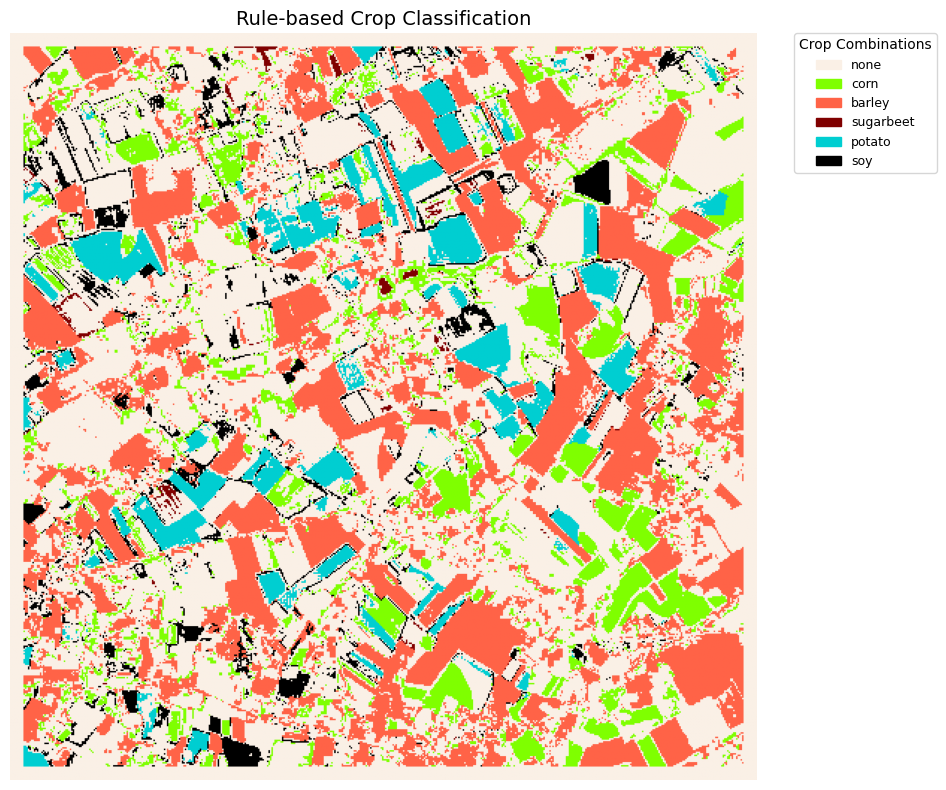

In [19]:
# keep only single-class pixels (corn, barley, sugarbeet, potato, soy); overlaps set to 0 ("none")
ds = np.where(np.isin(total_scaled, [1, 2, 4, 8, 16]), total_scaled, 0)

# only the crop labels we actually use
comb_used = {
    0: "none",
    1: "corn",
    2: "barley",
    4: "sugarbeet",
    8: "potato",
    16: "soy",
}

# preserve the original color indices for these classes
color_map = {
    0: "linen",
    1: "chartreuse",
    2: "tomato",
    4: "maroon",
    8: "darkturquoise",
    16: "black",
}

keys = np.unique(ds).astype(int)
labels = [comb_used[k] for k in keys]
colors = [color_map[k] for k in keys]

cmap = ListedColormap(colors)
class_bins = [-0.5] + [k + 0.5 for k in keys]
norm = BoundaryNorm(class_bins, len(colors))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(ds, cmap=cmap, norm=norm)
ax.set_title("Rule-based Crop Classification", fontsize=14)
ax.axis("off")

legend_patches = [Patch(color=colors[i], label=labels[i]) for i in range(len(labels))]
ax.legend(
    handles=legend_patches,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.0,
    fontsize=9,
    title="Crops",
)

plt.tight_layout()
plt.show()

In [20]:
cluster.close()

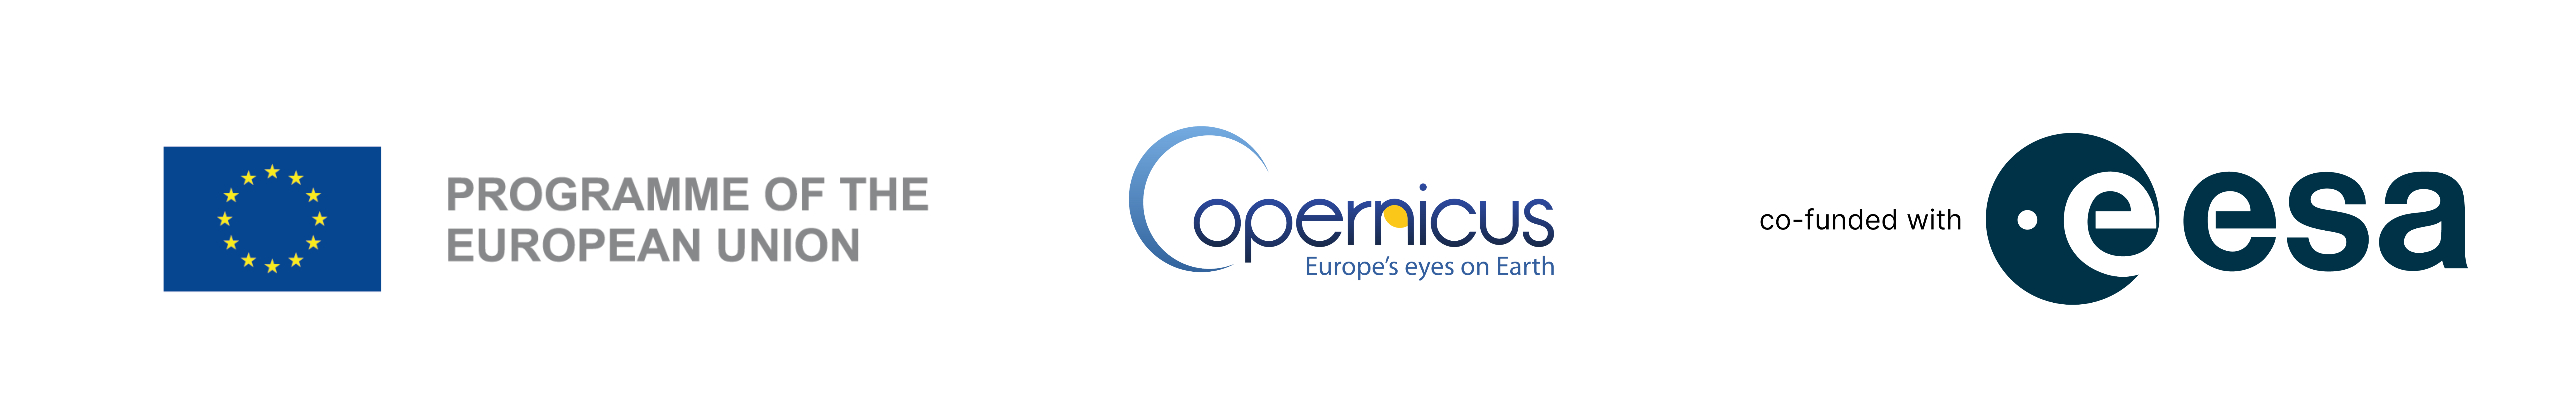